# 03 · Two-Tower Retrieval

The retrieval backbone of modern recommenders. A **user tower** and an **item tower** map ids into a shared vector space; the score is their dot product. We train with **in-batch negatives** (sampled softmax): within a mini-batch of (user, positive-item) pairs, every *other* item is treated as a negative.

Why this is the backbone:

- **Scales**: embed items once → nearest-neighbor lookup (FAISS) serves millions of items in milliseconds.
- **Extensible**: the item tower is where text / image / graph features plug in later. Swap the id lookup for an encoder over features and nothing else changes.

Here we compare it head-to-head with the Phase-1 baselines on the same temporal split.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")  # quiet BLAS threadpool warning
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from src.recsys.config import settings
from src.recsys.data import load_dataset
from src.recsys.eval import evaluate, temporal_split
from src.recsys.models import (
    ALSRecommender,
    ItemCFRecommender,
    PopularityRecommender,
    TwoTowerRecommender,
)

ds = load_dataset()
train, test_positives = temporal_split(ds.interactions)
test_users = list(test_positives.keys())
max_k = max(settings.eval_ks)
print(ds.summary())

Dataset(users=800, items=400, interactions=19,847, density=6.2022%, social_edges=4,619, has_images=True)


## Train the two-tower model

`verbose=True` prints the in-batch-negative loss per epoch — it should fall steadily. Try changing `dim`, `epochs`, `temperature`, or `normalize` and watch the effect on the metrics below.

In [2]:
tt = TwoTowerRecommender(dim=64, epochs=15, temperature=0.1, normalize=True, verbose=True)
tt.fit(train)
print("item embedding matrix:", tt._item_matrix.shape)

  epoch  1/15  loss=6.3211
  epoch  2/15  loss=4.6057


  epoch  3/15  loss=4.1022
  epoch  4/15  loss=3.8913


  epoch  5/15  loss=3.7752
  epoch  6/15  loss=3.7057


  epoch  7/15  loss=3.6619
  epoch  8/15  loss=3.6216


  epoch  9/15  loss=3.5920
  epoch 10/15  loss=3.5723


  epoch 11/15  loss=3.5525
  epoch 12/15  loss=3.5311


  epoch 13/15  loss=3.5158
  epoch 14/15  loss=3.5097


  epoch 15/15  loss=3.4965
item embedding matrix: (400, 64)


## Compare against the baselines

Same temporal split, same metrics. The only question that matters: does the neural retriever beat a well-tuned classical baseline?

In [3]:
models = {
    "popularity": PopularityRecommender(),
    "item_cf": ItemCFRecommender(top_n_neighbors=50),
    "als": ALSRecommender(factors=64, iterations=15),
    "two_tower": tt,  # already fitted above
}

results = {}
for name, model in models.items():
    if name != "two_tower":
        model.fit(train)
    recs = model.recommend(test_users, k=max_k)
    results[name] = evaluate(recs, test_positives, ks=settings.eval_ks, n_items=ds.n_items)

results_df = pd.DataFrame(results).T
results_df[[c for c in results_df.columns if c.endswith(f"@{settings.top_k}")]]

/Users/ruobingchen/Projects/recsys-lab/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,recall@10,ndcg@10,hitrate@10,precision@10,coverage@10
popularity,0.058457,0.044413,0.26375,0.029250,0.0425
item_cf,0.335440,0.315863,0.86000,0.164875,0.8275
als,0.228674,0.209383,0.72500,0.113500,0.9875
two_tower,0.287658,0.243722,0.79500,0.142000,1.0000


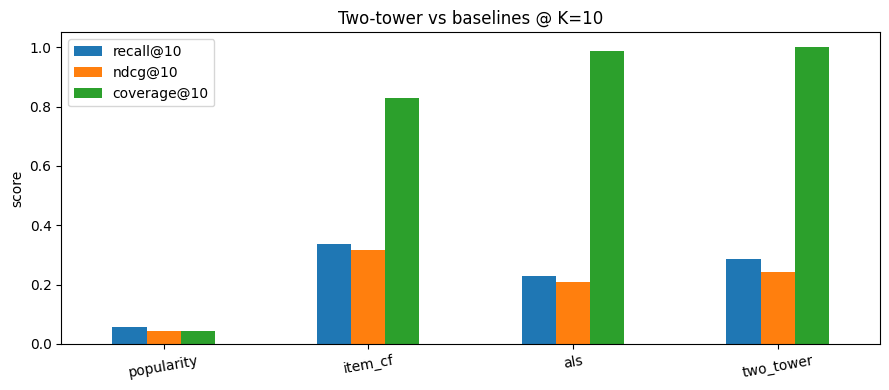

In [4]:
ax = results_df[[f"recall@{settings.top_k}", f"ndcg@{settings.top_k}", f"coverage@{settings.top_k}"]].plot.bar(
    figsize=(9, 4), rot=10, title=f"Two-tower vs baselines @ K={settings.top_k}"
)
ax.set_ylabel("score"); ax.figure.tight_layout()

## Takeaways & what's next

- On this dense **synthetic** data, item-CF is very strong (lots of clean co-occurrence), ALS is solid, and the **two-tower** matches/exceeds ALS with **full catalog coverage** — a sign it isn't just chasing popular items. On the real Yelp subset the ranking usually shifts.
- **Retrieval → ranking**: two-tower is the *retrieval* stage. Next you'd add a `ranker.py` (LightGBM) to re-rank its top candidates using rich features (including the two-tower score itself).
- **This is the injection point** for the modern signals: feed text (`text_embeddings.py`), image (`multimodal.py`), or graph (`graph.py`) features into the item tower.

**Next in our plan:** the **social** recommender (`models/social.py`) — using the real Yelp friend graph, with an honest lift measurement against these baselines, sliced by user activity.